# Grand Canyon Conditions

This notebook collects river, reservoir, and weather data useful for viewing recent and historical conditions in the Grand Canyon corridor. It focuses on Colorado River discharge at selected USGS gages, Lake Powell elevation, Lees Ferry water temperature, and Phantom Ranch air temperature.

The notebook produces two main figures:

1. A multi-year daily-values plot showing Colorado River discharge, Lake Powell elevation, and Phantom Ranch / Lees Ferry temperatures.
2. A shorter continuous-values plot showing higher-frequency discharge and water-temperature changes over a selected time window.

The notebook is designed to be rerun so that the daily-values plot can be updated with recent data.

## Data sources

### USGS Water Data

River discharge, Lees Ferry water temperature, and Lake Powell elevation are retrieved using the `waterdata` module from the USGS `dataretrieval` Python package.

This notebook uses:

- `waterdata.get_daily()` for daily values,
- `waterdata.get_continuous()` for higher-frequency continuous values.

The USGS Water Data API returns long/tidy tables with `parameter_code`, `statistic_id`, `time`, and `value` columns. The helper functions in `usgs_io.py` convert those returned tables into time-indexed dataframes suitable for plotting.

Useful USGS links:

- https://doi-usgs.github.io/dataretrieval-python/
- https://help.waterdata.usgs.gov/codes-and-parameters/parameters
- https://waterdata.usgs.gov/
- https://maps.waterdata.usgs.gov/mapper/

### NOAA/NCEI

Phantom Ranch air temperature data are retrieved from NOAA's National Centers for Environmental Information (NCEI), using the GHCN-Daily dataset through the helper module `ncei_io.py`.

The station used here is:

- Phantom Ranch, Arizona: `USC00026471`

Useful NCEI links:

- https://www.ncei.noaa.gov/
- https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

In [1]:
# Run this cell first when using Google Colab.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content

    if not Path("rivers").exists():
        !git clone -q https://github.com/gregorywanderson/rivers.git

    %cd /content/rivers/grand_canyon
    !pip install -q dataretrieval pandas matplotlib requests

# Make parent directory importable so notebooks can find ncei_io.py and usgs_io.py.
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
# Standard library
import datetime as dt
import importlib
import sys
from pathlib import Path

# Third party
import matplotlib.pyplot as plt
import pandas as pd
from dataretrieval import waterdata

# Local path setup
sys.path.insert(0, str(Path.cwd().parent))

# Local
import ncei_io as ncei
import usgs_io as usgs

try:
    import my_trips
except ModuleNotFoundError:
    my_trips = None

importlib.reload(ncei)
importlib.reload(usgs)

if my_trips is not None:
    importlib.reload(my_trips)

In [3]:
# ---------------------------------------------------------------------
# Analysis windows
# ---------------------------------------------------------------------
TZ = "America/Phoenix"

def local_timestamp(date_string, tz=TZ):
    """Convert YYYY-MM-DD string to a timezone-aware pandas Timestamp."""
    return pd.Timestamp(date_string, tz=tz)

# Today / yesterday in the local Grand Canyon (Arizona) time zone.
# Daily values often lag or may be incomplete for the current day, so
# YESTERDAY gives a more conservative fully-completed daily window.
TODAY = pd.Timestamp.now(tz=TZ).strftime("%Y-%m-%d")
YESTERDAY = (pd.Timestamp.now(tz=TZ) - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

# Long-window DAILY plot: fixed start through yesterday.
DAILY_START_DATE = "2020-01-01"
DAILY_END_DATE = YESTERDAY

# Short-window CONTINUOUS (sub-daily) plot: fixed start, length set by NDAYS.
NDAYS = 7
CONTINUOUS_START_DATE = "2025-06-01"
CONTINUOUS_END_DATE = (
    local_timestamp(CONTINUOUS_START_DATE) + pd.Timedelta(days=NDAYS)
).strftime("%Y-%m-%d")

DAILY_START = local_timestamp(DAILY_START_DATE)
DAILY_END = local_timestamp(DAILY_END_DATE)
CONTINUOUS_START = local_timestamp(CONTINUOUS_START_DATE)
CONTINUOUS_END = local_timestamp(CONTINUOUS_END_DATE)

# Convert the local continuous window to UTC for the USGS Water Data API.
CONTINUOUS_START_UTC = CONTINUOUS_START.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
CONTINUOUS_END_UTC = CONTINUOUS_END.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
CONTINUOUS_TIME = f"{CONTINUOUS_START_UTC}/{CONTINUOUS_END_UTC}"

# Optional: set to True if a local my_trips.py file is available.
SHOW_TRIPS = False

In [4]:
# Daily Summaries for mas/min/ave temp, precipitation, ...
# this cell can take a few minutes to run
met_pr = ncei.get_ghcnd_daily_summaries(
    station_id="USC00026471",   # Phantom Ranch, AZ
    start_date=DAILY_START_DATE,
    end_date=DAILY_END_DATE,
    data_types=["TMAX", "TMIN", "TAVG","PRCP"],
)
met_pr.columns

Index(['STATION', 'NAME', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'DATE'], dtype='str')

In [5]:
# USGS parameter codes and statistic IDs.
# USGS Water Data identifies each observation by BOTH a parameter_code and a
# statistic_id. Full list: https://help.waterdata.usgs.gov/codes-and-parameters/parameters

# --- Parameter codes ---
DISCHARGE           = "00060"  # Discharge (ft^3/s)
WATER_TEMPERATURE   = "00010"  # Water temperature (deg C)
AIR_TEMPERATURE     = "00020"  # Air temperature (deg C)
RESERVOIR_ELEVATION = "62615"  # Lake/reservoir elevation, NAVD 1988 (ft)
# Not yet used (uncomment as needed):
# GAGE_HEIGHT       = "00065"  # Gage height (ft)
# RES_ELEV_NGVD29   = "62614"  # Lake/reservoir elevation, NGVD 1929 (ft)
# TURBIDITY         = "63820"  # Turbidity (FNU)

# --- Statistic IDs ---
MAXIMUM       = "00001"  # Daily maximum
MINIMUM       = "00002"  # Daily minimum
MEAN          = "00003"  # Daily mean
INSTANTANEOUS = "00011"  # Instantaneous / continuous observation

HYDROPOWER_CUTOFF = 3490  # Lake Powell elevation (ft) below which hydropower stops
DEAD_POOL         = 3370  # Lake Powell elevation (ft) below which outlets can't pass water

### Selected USGS site numbers

For a complete list see 
  - https://waterdata.usgs.gov/nwis/inventory or 
  - https://maps.waterdata.usgs.gov/mapper/index.html

In [ ]:
# Reservoirs: the Bureau of Reclamation is the definitive source
# for reservoir operations data.

LAKE_POWELL = "USGS-09379900"

# Colorado River gauges
CR_LEES_FERRY    = "USGS-09380000"
CR_PHANTOM_RANCH = "USGS-09402500"  # Near Phantom Ranch, just upstream from the Black suspension bridge
CR_DIAMOND_CREEK = "USGS-09404200"

# Tributary gauges
PR  = "USGS-09382000"  # Paria River at Lee's Ferry, AZ
LC1 = "USGS-09402300"  # Little Colorado River just above the mouth
LC2 = "USGS-09402000"  # Little Colorado River near Cameron, AZ
KC  = "USGS-09403850"  # Kanab Creek, just above the mouth
HC  = "USGS-09404115"  # Havasu Creek
BA  = "USGS-09403000"  # Bright Angel Creek

## Daily Values

In [7]:
# DailyLake Level
daily_lp, md_lp = waterdata.get_daily(
    monitoring_location_id=LAKE_POWELL,
    parameter_code=RESERVOIR_ELEVATION, # Lake Powell water level
    statistic_id=MEAN, 
    time=f"{DAILY_START_DATE}/{DAILY_END_DATE}",
)

daily_lp = usgs.wrangle_waterdata_timeseries(
    daily_lp,
    value_name="elevation_ft",
    tz=TZ,
)
daily_lp.head()

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,elevation_ft,unit_of_measure,approval_status,qualifier,last_modified,daily_id
time,,,,,,,,,,,
2020-01-01 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.2,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,d370bb5f-c340-42d4-86bd-50f71cfde229
2020-01-02 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.1,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,3cabd323-cf90-477f-8a60-07f3f098fb8b
2020-01-03 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3611.0,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,326f83d4-77df-481a-a253-d09dc9a558a1
2020-01-04 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3610.9,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,2a302c57-5a83-4ed4-a4da-b8bf1cf0fd07
2020-01-05 00:00:00-07:00,POINT (-111.48405 36.93665),a1ac1fb483a748e98e53da30676756d4,USGS-09379900,62615,00003,3610.8,ft,Approved,None,2025-03-11 21:42:56.796363+00:00,fe9e5e3e-bfa2-446c-9873-ff20c383c2bc


In [ ]:
# Daily discharge on the Colorado River
# Lees Ferry also includes daily water temperature.

daily_lf, md_lf = waterdata.get_daily(
    monitoring_location_id=CR_LEES_FERRY,
    parameter_code=[DISCHARGE, WATER_TEMPERATURE],
    statistic_id=MEAN,
    time=f"{DAILY_START_DATE}/{DAILY_END_DATE}",
)

daily_lf = usgs.wrangle_waterdata_timeseries(daily_lf, tz=TZ)

daily_lf = usgs.waterdata_to_wide(
    daily_lf,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
        (WATER_TEMPERATURE, MEAN): "water_temperature_c",
    },
)


daily_pr, md_pr = waterdata.get_daily(
    monitoring_location_id=CR_PHANTOM_RANCH,
    parameter_code=DISCHARGE,
    statistic_id=MEAN,
    time=f"{DAILY_START_DATE}/{DAILY_END_DATE}",
)

daily_pr = usgs.wrangle_waterdata_timeseries(daily_pr, tz=TZ)

daily_pr = usgs.waterdata_to_wide(
    daily_pr,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
    },
)


daily_d, md_d = waterdata.get_daily(
    monitoring_location_id=CR_DIAMOND_CREEK,
    parameter_code=DISCHARGE,
    statistic_id=MEAN,
    time=f"{DAILY_START_DATE}/{DAILY_END_DATE}",
)

daily_d = usgs.wrangle_waterdata_timeseries(daily_d, tz=TZ)

daily_d = usgs.waterdata_to_wide(
    daily_d,
    names={
        (DISCHARGE, MEAN): "discharge_cfs",
    },
)

### Plot Daily Values

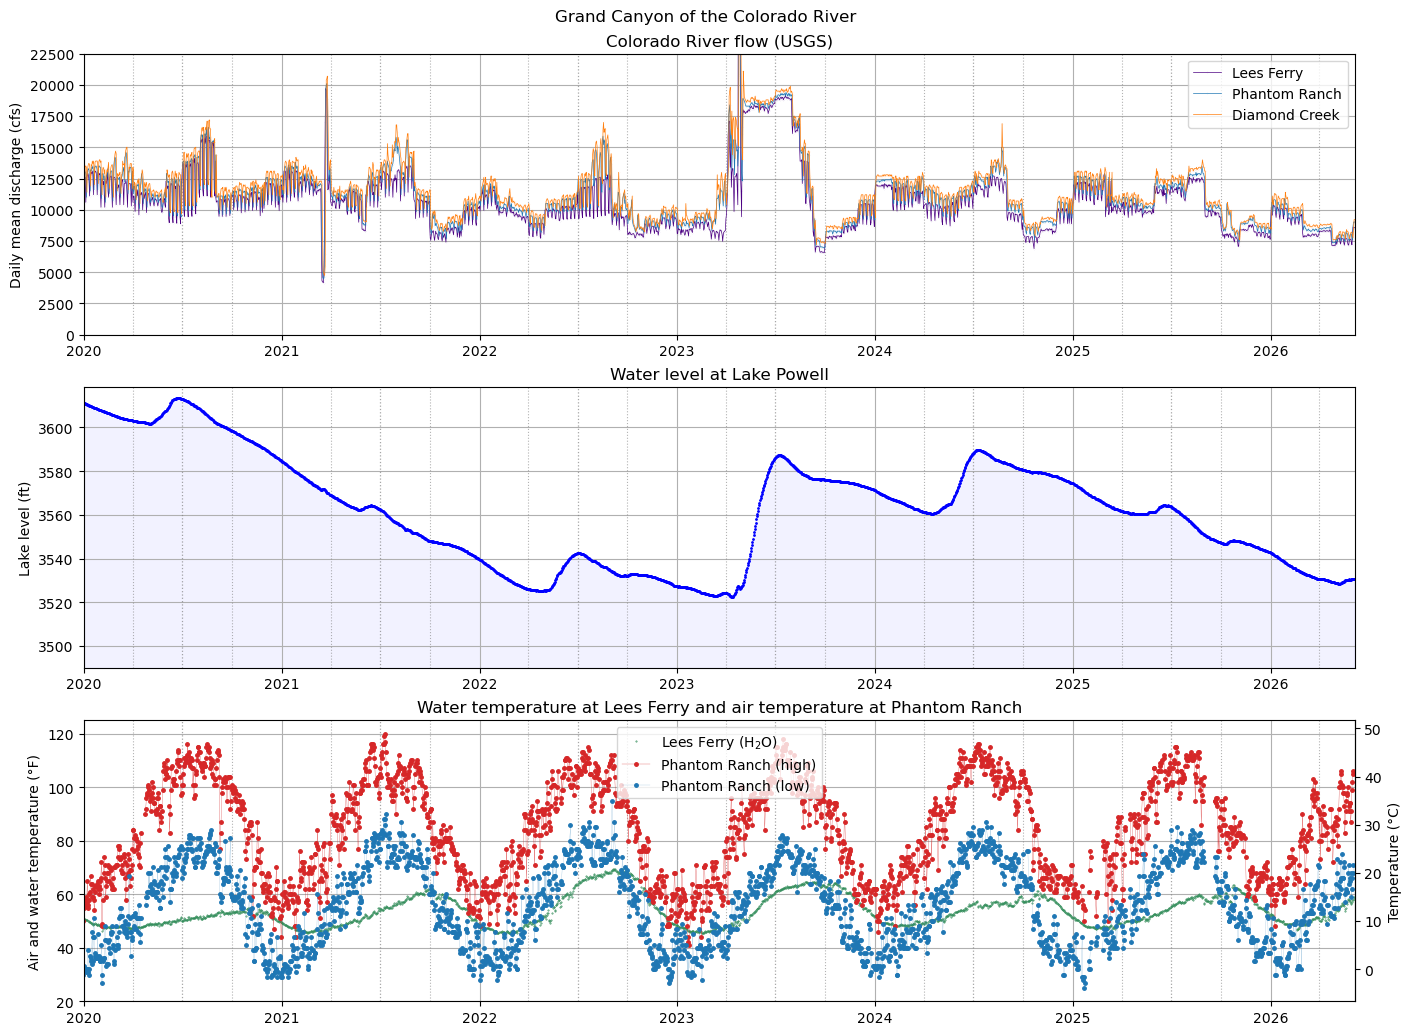

In [9]:
# Plot daily values for multiple years

DAILY_START = pd.Timestamp(DAILY_START_DATE, tz=TZ)
DAILY_END = pd.Timestamp(DAILY_END_DATE, tz=TZ)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(14, 10), constrained_layout=True
)

fig.suptitle("Grand Canyon of the Colorado River", y=1.02)

axes = (ax1, ax2, ax3)

# Quarter and midyear vertical reference lines.
years = range(DAILY_START.year, DAILY_END.year + 1)

for year in years:
    q1_end = pd.Timestamp(f"{year}-04-01", tz=TZ)
    midyear = pd.Timestamp(f"{year}-07-01", tz=TZ)
    q4_begin = pd.Timestamp(f"{year}-10-01", tz=TZ)

    for ax in axes:
        if DAILY_START <= q1_end <= DAILY_END:
            ax.axvline(
                q1_end,
                linestyle=":",
                linewidth=0.8,
                alpha=0.6,
                color="gray",
            )

        if DAILY_START <= midyear <= DAILY_END:
            ax.axvline(
                midyear,
                linestyle=":",
                linewidth=0.9,
                alpha=0.7,
                color="gray",
            )

        if DAILY_START <= q4_begin <= DAILY_END:
            ax.axvline(
                q4_begin,
                linestyle=":",
                linewidth=0.8,
                alpha=0.6,
                color="gray",
            )

if SHOW_TRIPS:
    for ax in axes:
        my_trips.add_trip_spans(ax, tz=TZ, alpha=0.12)

# ---------------------------------------------------------------------
# Daily mean discharge
# ---------------------------------------------------------------------

ax1.grid(True)
ax1.axis([DAILY_START, DAILY_END, 0, 22500])
ax1.set_ylabel("Daily mean discharge (cfs)")
ax1.set_title("Colorado River flow (USGS)")

ax1.plot(
    daily_lf.index,
    daily_lf["discharge_cfs"],
    color="indigo",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Lees Ferry",
    linewidth=0.5,
)

ax1.plot(
    daily_pr.index,
    daily_pr["discharge_cfs"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Phantom Ranch",
    linewidth=0.5,
)

ax1.plot(
    daily_d.index,
    daily_d["discharge_cfs"],
    color="tab:orange",
    linestyle="solid",
    marker="o",
    markersize=0.02,
    label="Diamond Creek",
    linewidth=0.5,
)

ax1.legend()

# ---------------------------------------------------------------------
# Lake Powell water level
# ---------------------------------------------------------------------

ax2.grid(True)
ax2.axis(
    [
        DAILY_START,
        DAILY_END,
        HYDROPOWER_CUTOFF,
        daily_lp["elevation_ft"].max() + 5,
    ]
)

ax2.fill_between(
    daily_lp.index,
    daily_lp["elevation_ft"],
    color="blue",
    alpha=0.05,
)

ax2.plot(
    daily_lp.index,
    daily_lp["elevation_ft"],
    color="blue",
    linestyle="none",
    marker="o",
    markersize=1,
    linewidth=1,
)

ax2.set_ylabel("Lake level (ft)")
ax2.set_title("Water level at Lake Powell")

# ---------------------------------------------------------------------
# Air and water temperature
# ---------------------------------------------------------------------

ax3.axis([DAILY_START, DAILY_END, 20, 125])
ax3.grid(True)

ax3.plot(
    daily_lf.index,
    9 * daily_lf["water_temperature_c"] / 5 + 32,
    color="seagreen",
    linestyle="none",
    marker="o",
    markersize=0.4,
    label="Lees Ferry (H${}_2$O)",
    linewidth=0.5,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMAX"],
    color="tab:red",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (high)",
    linewidth=0.2,
)

ax3.plot(
    met_pr["DATE"],
    met_pr["TMIN"],
    color="tab:blue",
    linestyle="solid",
    marker="o",
    markersize=2.5,
    label="Phantom Ranch (low)",
    linewidth=0.1,
)

ax3.legend()

ax3.set_ylabel("Air and water temperature (°F)")
ax3.set_title(
    "Water temperature at Lees Ferry and air temperature at Phantom Ranch"
)

ax3_secondary = ax3.secondary_yaxis(
    "right",
    functions=(
        lambda temp_f: (temp_f - 32) * 5 / 9,
        lambda temp_c: temp_c * 9 / 5 + 32,
    ),
)

ax3_secondary.set_ylabel("Temperature (°C)")

Path("figures").mkdir(exist_ok=True)

plt.savefig("figures/gc_conditions.pdf")
plt.savefig("figures/gc_conditions.png")
plt.show()

## Continuous Values

In [10]:
# Continuous discharge on the Colorado River
# Lees Ferry also includes water temperature.

continuous_lf, md_continuous_lf = waterdata.get_continuous(
    monitoring_location_id=CR_LEES_FERRY,
    parameter_code=[DISCHARGE, WATER_TEMPERATURE],
    time=CONTINUOUS_TIME,
)

continuous_lf = usgs.wrangle_waterdata_timeseries(continuous_lf, tz=TZ)

continuous_lf = usgs.waterdata_to_wide(
    continuous_lf,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
        (WATER_TEMPERATURE, INSTANTANEOUS): "water_temperature_c",
    },
)


continuous_pr, md_continuous_pr = waterdata.get_continuous(
    monitoring_location_id=CR_PHANTOM_RANCH,
    parameter_code=DISCHARGE,
    time=CONTINUOUS_TIME,
)

continuous_pr = usgs.wrangle_waterdata_timeseries(continuous_pr, tz=TZ)

continuous_pr = usgs.waterdata_to_wide(
    continuous_pr,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
    },
)


continuous_d, md_continuous_d = waterdata.get_continuous(
    monitoring_location_id=CR_DIAMOND_CREEK,
    parameter_code=DISCHARGE,
    time=CONTINUOUS_TIME,
)

continuous_d = usgs.wrangle_waterdata_timeseries(continuous_d, tz=TZ)

continuous_d = usgs.waterdata_to_wide(
    continuous_d,
    names={
        (DISCHARGE, INSTANTANEOUS): "discharge_cfs",
    },
)

### Plot Tides

Rafters often call the daily rise and fall in discharge from Glen Canyon Dam hydropower releases “tides.” The timing and size of these pulses can vary with weekday/weekend electricity demand, dam operations, and downstream travel time. The times shown here are the observed arrival times at USGS gages, not the release times at Glen Canyon Dam.

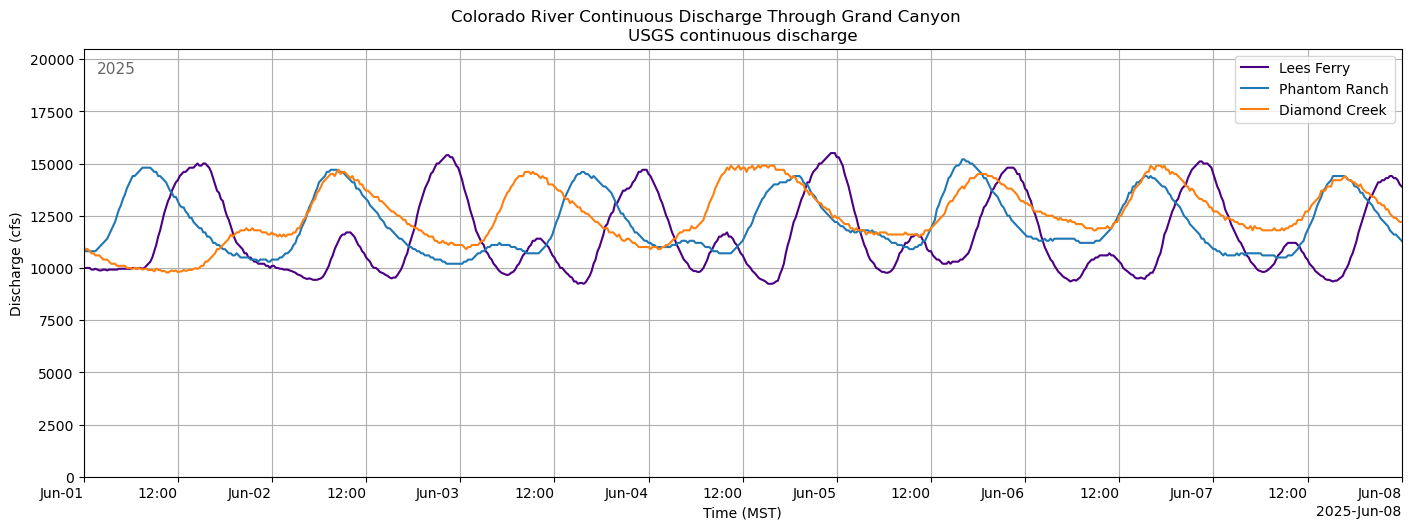

In [ ]:
# Plot continuous discharge values
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo
from pathlib import Path

CONTINUOUS_START = pd.Timestamp(CONTINUOUS_START_DATE, tz=TZ)
CONTINUOUS_END = pd.Timestamp(CONTINUOUS_END_DATE, tz=TZ)

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
fig.suptitle("Flow of the Colorado River Through Grand Canyon", y=1.03)
ax.grid(True)
ax.axis([CONTINUOUS_START, CONTINUOUS_END, 0, 20500])
ax.set_ylabel("Discharge (cfs)")
ax.set_title("USGS continuous discharge")

ax.plot(
    continuous_lf.index, continuous_lf["discharge_cfs"],
    color="indigo", marker="o", markersize=0.02,
    label="Lees Ferry", linewidth=1.5,
)
ax.plot(
    continuous_pr.index, continuous_pr["discharge_cfs"],
    color="tab:blue", marker="o", markersize=0.02,
    label="Phantom Ranch", linewidth=1.5,
)
ax.plot(
    continuous_d.index, continuous_d["discharge_cfs"],
    color="tab:orange", marker="o", markersize=0.02,
    label="Diamond Creek", linewidth=1.5,
)
ax.legend()

# Keep explicit 12-hour ticks, but let ConciseDateFormatter strip
# repeated context (year shown once at the axis edge, bare day/time per tick).
locator = mdates.HourLocator(interval=12, tz=ZoneInfo(TZ))
formatter = mdates.ConciseDateFormatter(locator, tz=ZoneInfo(TZ))
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Single MST note instead of repeating it on every tick.
ax.set_xlabel("Time (MST)")

# Year as one annotation inside the axes (top-left).
ax.annotate(
    CONTINUOUS_START.strftime("%Y"),
    xy=(0.01, 0.97), xycoords="axes fraction",
    ha="left", va="top", fontsize=11, color="0.4",
)

fig.autofmt_xdate(rotation=0)

Path("figures").mkdir(parents=True, exist_ok=True)
plt.savefig("figures/gc_continuous_discharge.pdf")
plt.savefig("figures/gc_continuous_discharge.png")
plt.show()

### On the timing and travel of discharge waves in the canyon

Releases at the Glenn Canyon Dam typically peak on weekdays between 4pm and 7pm local time.  The differences between peaks and valleys are most dramatic in the summer, when demands for electricity increase, and less pronounced on weekends.
Measurements of water speed on the Colorado River between Glen Canyon Dam and Lees Ferry have been measured at discharges of 5k, 15k and 23k cfs using fluoresent dye.
At the highest releases, water moved at $v=2.3$ mph and took 7 hours to travel from the dam to Lees Ferry, 
while at the lowest release, water moved at $v=0.7$ mph it took 22 hours. The average water speed is proportional to the discharge.  For more information I highly recommend the USGS publication https://pubs.usgs.gov/fs/FS-168-97/pdf/fs-168-97.pdf.

Discharge peaks travel **faster** than the water.  These are *waves* moving downstream. The equation for the speed ($c$) of a shallow water wave moving donwstream in a current of speed ($v$) and depth ($h$) is
$$c = \sqrt{gh} + v$$

In one of the high discharge events described in the reference above, the wave speed was 2&mdash;3 times faster than the speed of the water. 
Based on the reference above, I would estimate the wave peak took between 5 and 6 hours to travel from the dam to Lees ferry.

The shape of the wave also changes as it move downstream.


Shallow water wave relation for the wave propagation speed 
$c = \sqrt{gh} + v$, 
where $h$ is the water depth, and $v$ is the stream speed.


A river channel acts exactly like a low-pass filter in an electrical circuit.

  - Sharp, rapid changes in discharge (high-frequency signals, like the small secondary peak) represent localized gradients in hydraulic head.

  - As these small pulses hit the massive volume of the canyon's pools and recirculating eddies, they are rapidly sheared and diffused. The water from the small peak fills up the local storage capacity of the eddies, flattening the spike out entirely before it can travel very far downstream.
    
  - The large, broad daily peak has a much lower frequency (a 24-hour wavelength), allowing it to survive the journey all the way to Diamond Creek, albeit smoothed out.


In [12]:
# Daily peak discharge at Lees Ferry (MST)
peak_lf = (
    continuous_lf["discharge_cfs"]
    .groupby(continuous_lf.index.normalize())          # group by local calendar day
    .agg(peak_cfs="max", peak_time=lambda s: s.idxmax())
)
peak_lf["peak_hour_mst"] = peak_lf["peak_time"].dt.strftime("%H:%M")

print(peak_lf[["peak_cfs", "peak_time", "peak_hour_mst"]].to_string())

                           peak_cfs                 peak_time peak_hour_mst
time                                                                       
2025-06-01 00:00:00-07:00   15000.0 2025-06-01 14:30:00-07:00         14:30
2025-06-02 00:00:00-07:00   15400.0 2025-06-02 22:15:00-07:00         22:15
2025-06-03 00:00:00-07:00   14700.0 2025-06-03 23:15:00-07:00         23:15
2025-06-04 00:00:00-07:00   15500.0 2025-06-04 23:15:00-07:00         23:15
2025-06-05 00:00:00-07:00   15300.0 2025-06-05 00:00:00-07:00         00:00
2025-06-06 00:00:00-07:00   15100.0 2025-06-06 22:15:00-07:00         22:15
2025-06-07 00:00:00-07:00   14500.0 2025-06-07 00:00:00-07:00         00:00
2025-06-08 00:00:00-07:00   13900.0 2025-06-08 00:00:00-07:00         00:00


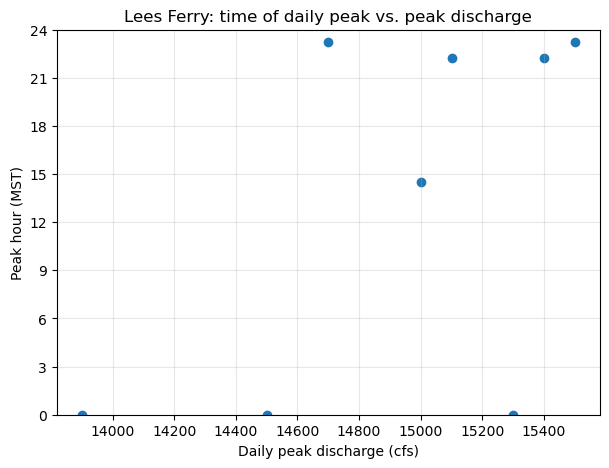

In [13]:
# Peak hour as a numeric value (hours since local midnight) for plotting
hour_numeric = (
    peak_lf["peak_time"].dt.hour
    + peak_lf["peak_time"].dt.minute / 60
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(peak_lf["peak_cfs"], hour_numeric)
ax.set_xlabel("Daily peak discharge (cfs)")
ax.set_ylabel("Peak hour (MST)")
ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 3))
ax.set_title("Lees Ferry: time of daily peak vs. peak discharge")
ax.grid(True, alpha=0.3)
plt.show()